## Player Action Radius / Radios de Accion por Jugador

This notebook performs a visual analysis of a football player's activity during a match by generating an action-radius plot and a heatmap based on event coordinates.

### What the notebook does

1. Loads the event data from a CSV file.
2. Filters the dataset to keep only the events of a specific team or player (using teamId or playerId).
3. Selects specific event types, such as passes, to focus the analysis.
4. Cleans the data by removing extreme outliers in the x and y coordinates using Z-score filtering.
5. Converts the coordinate columns into NumPy arrays for use in plotting functions.
6. Draws a StatsBomb-style pitch and adjusts colours, orientation and layout.
7. Generates a KDE heatmap to visualise where the player interacted most on the pitch.
8. Prepares the setup for further analysis, such as passing maps or convex hull action areas.

### Purpose of the analysis

The goal is to visually understand the areas of influence of a player during the match, identify where they participated most, and create tools for analysing passes, shots or any other event type present in the dataset.

### Visual Analysis. 

This first example focuses on the action radius of a player or a team, to see exactly in which areas they performed certain actions, such as passes, shots, etc.

We will neeed a CSV file to get the data. This CSV is already preprocessed, but you can also use any CSV from sources like Understat, FBref, or any dataset.

These datasets can cotain the events you are interested in: action radius, shot maps, player comparisons, or other visualizations.

In [1]:
# Install libraries

!pip install mplsoccer --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.2 MB/s eta 0:00:00


In [2]:
# Import libraries

import pandas as pd
import seaborn as sns
from mplsoccer import Pitch
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull
from scipy import stats

In [3]:
df = pd.read_csv("/kaggle/input/visual-analysis-action-radius-football-analysis/convextutorial.csv")
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
0,2,0,0.0,65,0.0,0.0,NaN,Start,32
1,2,0,0.0,833,0.0,0.0,NaN,Start,32
2,3,0,1.0,833,50.8,51.5,303800.0,Pass,1
3,4,0,4.0,833,28.4,58.4,316957.0,Pass,1
4,5,0,7.0,833,66.6,24.7,303800.0,BallTouch,61
...,...,...,...,...,...,...,...,...,...
1576,1018,92,7.0,65,0.0,0.0,NaN,End,30
1577,1019,0,0.0,65,0.0,0.0,NaN,End,30
1578,676,0,0.0,833,0.0,0.0,NaN,End,30
1579,1,0,0.0,65,0.0,0.0,NaN,FormationSet,34


## Clean Data Processing


In [4]:
print('Any NaN?',df.isna().any().any()) # False
print(df.isna().sum())
print('Show me all the rows where there is at least one NaN.',df[df.isna().any(axis=1)])
print('any inf number? ',np.isinf(df['x']).any())
print('any inf number? ',np.isinf(df['y']).any())

Any NaN? True
eventId              0
minute               0
second               2
teamId               0
x                    0
y                    0
playerId            12
type/displayName     0
type/value           0
dtype: int64
Show me all the rows where there is at least one NaN.       eventId  minute  second  teamId     x     y  playerId type/displayName  \
0           2       0     0.0      65   0.0   0.0       NaN            Start   
1           2       0     0.0     833   0.0   0.0       NaN            Start   
23      11027       1     NaN     833  92.3  69.4  135098.0     OffsideGiven   
328     11204      18     NaN      65  82.7  17.6       7.0     OffsideGiven   
756       350      45     1.0     833   0.0   0.0       NaN              End   
757       468      45     1.0      65   0.0   0.0       NaN              End   
758       352      45     0.0     833   0.0   0.0       NaN            Start   
759       469      45     0.0      65   0.0   0.0       NaN            S

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [5]:
df = df.fillna(0)
df

,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
0,2,0,0.0,65,0.0,0.0,0.0,Start,32
1,2,0,0.0,833,0.0,0.0,0.0,Start,32
2,3,0,1.0,833,50.8,51.5,303800.0,Pass,1
3,4,0,4.0,833,28.4,58.4,316957.0,Pass,1
4,5,0,7.0,833,66.6,24.7,303800.0,BallTouch,61
...,...,...,...,...,...,...,...,...,...
1576,1018,92,7.0,65,0.0,0.0,0.0,End,30
1577,1019,0,0.0,65,0.0,0.0,0.0,End,30
1578,676,0,0.0,833,0.0,0.0,0.0,End,30
1579,1,0,0.0,65,0.0,0.0,0.0,FormationSet,34


### Now we can make sure that the dataset is clean and ready

In [6]:
print('Any NaN?',df.isna().any().any()) # False
print(df.isna().sum())
print('Show me all the rows where there is at least one NaN.',df[df.isna().any(axis=1)])
print('any inf number? ',np.isinf(df['x']).any())
print('any inf number? ',np.isinf(df['y']).any())

Any NaN? False
eventId             0
minute              0
second              0
teamId              0
x                   0
y                   0
playerId            0
type/displayName    0
type/value          0
dtype: int64
Show me all the rows where there is at least one NaN. Empty DataFrame
Columns: [eventId, minute, second, teamId, x, y, playerId, type/displayName, type/value]
Index: []
any inf number?  False
any inf number?  False


In [7]:
# These are the Pitch sizes we need to convert/normalize

df['x'] = df['x']*1.2
df['y'] = df['y']*.8
df.head()

,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
0,2,0,0.0,65,0.00,0.00,0.0,Start,32
1,2,0,0.0,833,0.00,0.00,0.0,Start,32
2,3,0,1.0,833,60.96,41.20,303800.0,Pass,1
3,4,0,4.0,833,34.08,46.72,316957.0,Pass,1
4,5,0,7.0,833,79.92,19.76,303800.0,BallTouch,61


### Choose one of the team Ids.
Lets run a command to see how many team ids do we have...

In [8]:
df['teamId'].unique()

array([ 65, 833])

### In my case, I will choose 65

With the following command I will:
1. Filter the Dataframe by teamId. I will keep *only the rows where teamId is 65*. Keep the data only from team id 65
2. With `reset_index()` resets the indexes to 0, 1, 2... so that the filtered DataFrame has consecutive indexes.

In [9]:
df = df[df['teamId']==65].reset_index(drop=True)
df

,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
0,2,0,0.0,65,0.00,0.00,0.0,Start,32
1,3,0,8.0,65,33.48,64.48,5.0,BallRecovery,49
2,4,0,9.0,65,36.72,51.44,5.0,Pass,1
3,5,0,13.0,65,31.68,17.92,28.0,Pass,1
4,6,0,18.0,65,35.04,30.16,4.0,Pass,1
...,...,...,...,...,...,...,...,...,...
955,1016,92,3.0,65,110.64,50.40,17.0,Dispossessed,50
956,1017,92,6.0,65,90.72,66.80,5.0,Interception,8
957,1018,92,7.0,65,0.00,0.00,0.0,End,30
958,1019,0,0.0,65,0.00,0.00,0.0,End,30


### Convert the float values of playerId into int values and give me the 11 starter players

In [10]:
df['playerId'] = df['playerId'].astype(int)
player_ids = df['playerId'].unique()
print(player_ids)

starters = player_ids[0:11]
print('starters' , starters)

[ 0  5 28  4 23  7 11 21  1  9 18 16 17 12]
starters [ 0  5 28  4 23  7 11 21  1  9 18]


### Individual Action Radius for a specific Player

How can we visualise the action radius of a *specific player*. 

We want to look only at the passes they made, so we filter by passes. 
However, you can replace “passes” with any other event from the CSV.

**Remember:** Use the PlayerID for the player you want, or the exact type/value (for passes, shots, etc.) as it appears in the CSV, otherwise it will return an error.

### Individual Action Radius for player

Filter by
1. Player Id
2. Value 1 of Type / value

In [11]:
player_df = df[df['playerId']==21] # Get this player
player_df = player_df[player_df['type/value']==1] # Get this passes
player_df

,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
17,19,1,40.0,65,40.32,2.32,21,Pass,1
48,54,4,34.0,65,76.56,21.84,21,Pass,1
103,115,10,22.0,65,70.44,22.64,21,Pass,1
111,123,11,39.0,65,88.32,16.56,21,Pass,1
116,128,12,14.0,65,48.96,11.44,21,Pass,1
...,...,...,...,...,...,...,...,...,...
895,953,85,40.0,65,82.68,15.36,21,Pass,1
920,980,88,3.0,65,73.44,15.60,21,Pass,1
928,988,88,27.0,65,118.08,29.04,21,Pass,1
940,1000,90,53.0,65,49.44,16.96,21,Pass,1


### Delete outliers 

#### What does this line of code do?

`player_df[['x','y']]`

1. Selects only the x and y columns from the player_df DataFrame (the event coordinates).

`stats.zscore(...)`

2. Calculates the Z-score for each value in x and y.
The Z-score measures how many standard deviations a value is from the mean:

`Z = X−mean / standard deviation`

Values with a high |Z| are considered potential outliers.

`np.abs(... ) < 3`

3. Takes the absolute value of the Z-score and selects only those less than 3.

4. This means only points that are within 3 standard deviations of the mean in x and y are kept.

Very distant points (outliers) are removed.

`player_df[...]`

5. Filters the DataFrame, keeping only the rows that meet the condition.
6. This way, player_df is cleaned of extremely distant coordinates that could distort the heatmap or the action radius analysis.

In [12]:
# Delete outliers

player_df = player_df[np.abs(stats.zscore(player_df[['x','y']])) < 3]
player_df

,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
17,19,1,40.0,65,40.32,2.32,21,Pass,1
48,54,4,34.0,65,76.56,21.84,21,Pass,1
103,115,10,22.0,65,70.44,22.64,21,Pass,1
111,123,11,39.0,65,88.32,16.56,21,Pass,1
116,128,12,14.0,65,48.96,11.44,21,Pass,1
...,...,...,...,...,...,...,...,...,...
895,953,85,40.0,65,82.68,15.36,21,Pass,1
920,980,88,3.0,65,73.44,15.60,21,Pass,1
928,988,88,27.0,65,118.08,29.04,21,Pass,1
940,1000,90,53.0,65,49.44,16.96,21,Pass,1


In [13]:
# Save in a numpy list the values from columns X and Y from the DF

'''
array([[ 40.32,   2.32],
       [ 76.56,  21.84],
       [ 70.44,  22.64],
'''

points = player_df[['x','y']].values
# points 

## Action Ratio Zone 

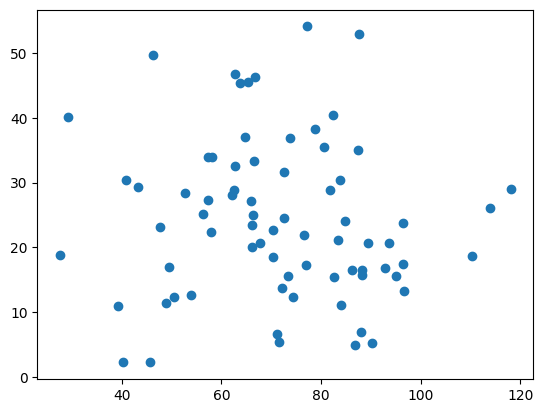

In [14]:
hull = ConvexHull(points)

plt.scatter(player_df['x'], 
            player_df['y'])

### Display the Ratio in the Pitch

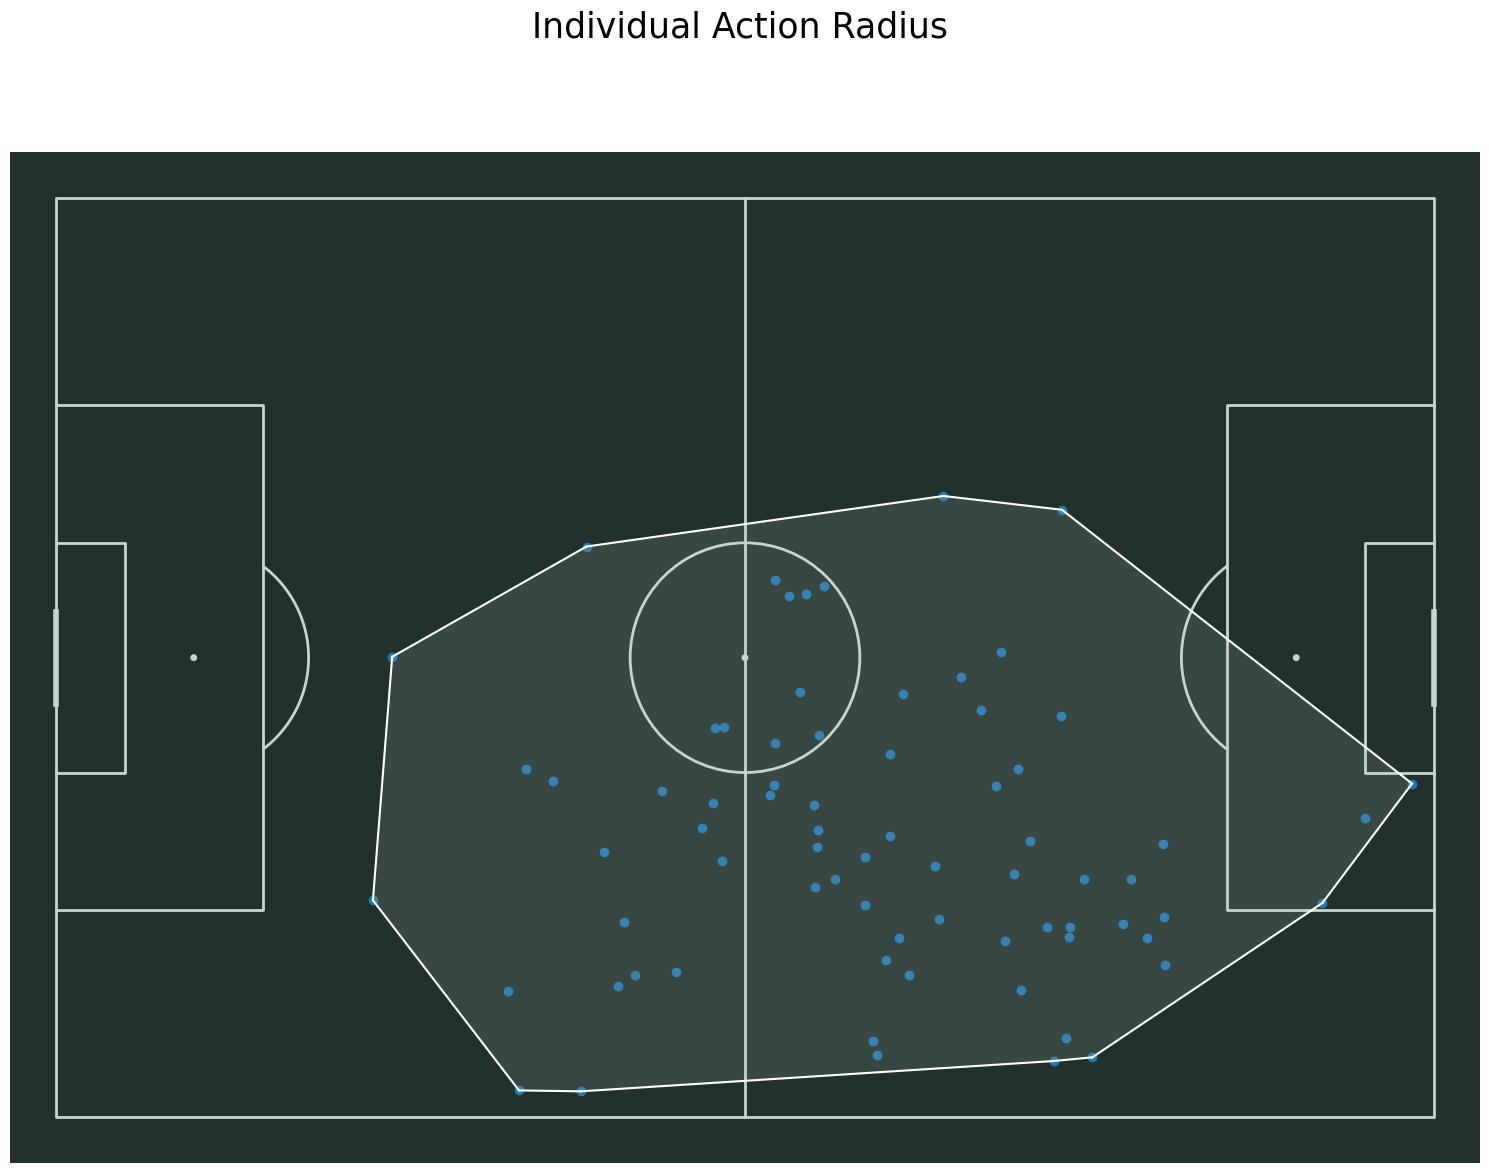

In [15]:
# Create the Pitch and normalize with the data
pitch = Pitch(pitch_type='statsbomb', 
              pitch_color='#22312b',
              line_color='#c7d5cc'
             )

fig, ax = pitch.draw(figsize=(15,13),
                    constrained_layout=True,
                    tight_layout=True)

plt.gca().invert_yaxis()

plt.suptitle("Individual Action Radius ", 
             fontsize=25)

plt.scatter(player_df['x'], 
            player_df['y'])

for i in hull.simplices:
    plt.plot(points[i,0], points[i,1], 'white')
    
    plt.fill(points[hull.vertices, 0], 
             points[hull.vertices,1],
             c='white',
             alpha=.01)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


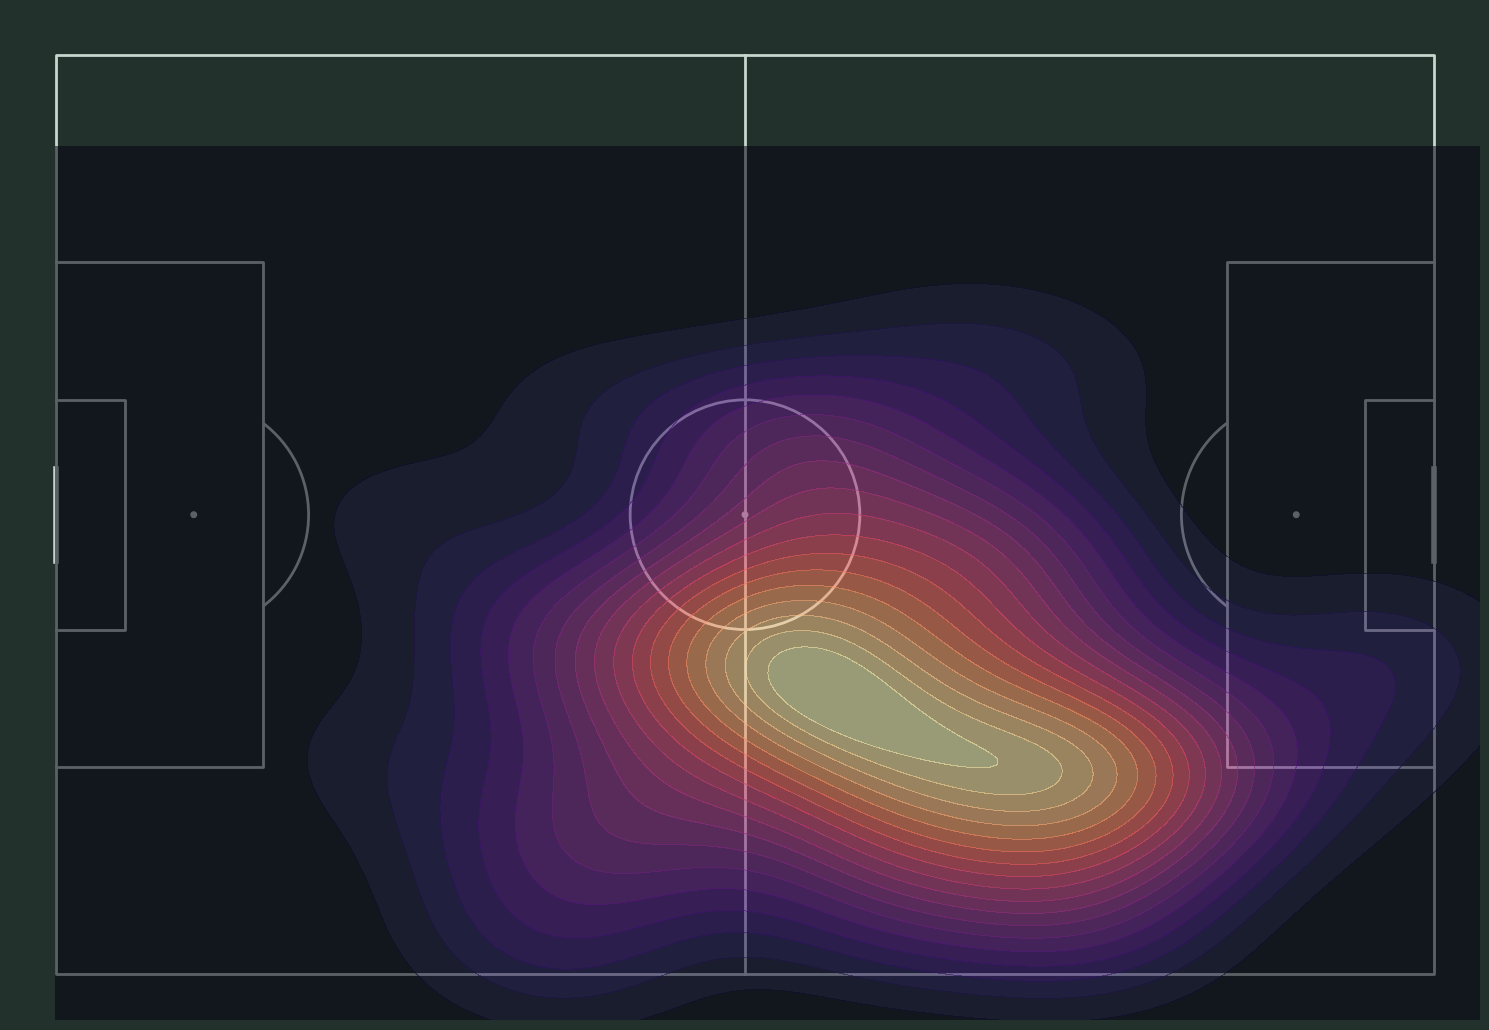

In [16]:
# Pitch setup 
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#22312b',
    line_color='#c7d5cc'
)

fig, ax = pitch.draw(figsize=(15,13), 
                     constrained_layout=True, 
                     tight_layout=True)

fig.set_facecolor('#22312b')

# This is necessary to match with StatsBomb system
plt.gca().invert_yaxis()

# KDE Heatmap
sns.kdeplot(
    # data=df,
    data=player_df,
    x='x',
    y='y',
    fill=True,
    thresh=0,
    alpha=0.55,
    levels=20,
    cmap='magma'
)

plt.show()
